In [1]:
# ======================================================
# STEP 1: IMPORT LIBRARIES
# ======================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [18]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

print(train.shape)
print(test.shape)

(42000, 785)
(17806, 784)


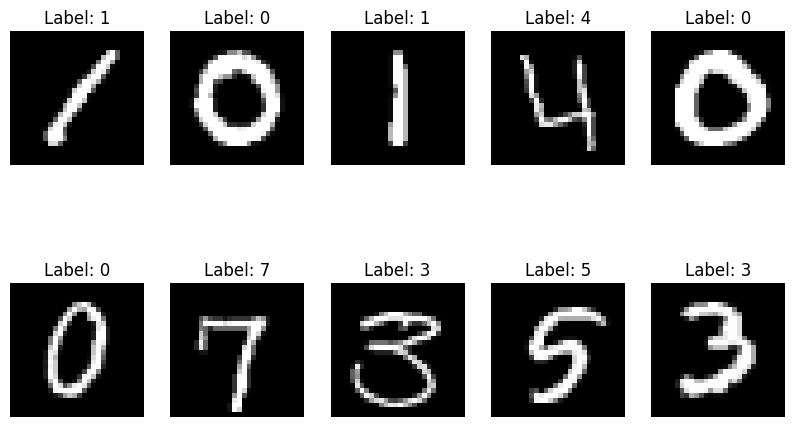

In [19]:
# ======================================================
# STEP 3: VISUALIZE DIGITS
# ======================================================

plt.figure(figsize=(10,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    image = train.iloc[i,1:].values.reshape(28,28)

    plt.imshow(image, cmap="gray")
    plt.title("Label: " + str(train.iloc[i,0]))
    plt.axis("off")

plt.show()

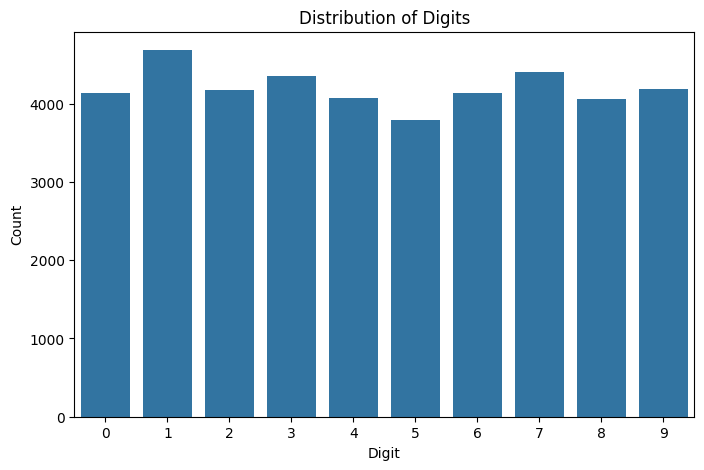

In [21]:
# ======================================================
# STEP 4: CHECK CLASS DISTRIBUTION
# ======================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(x=train["label"])

plt.title("Distribution of Digits")
plt.xlabel("Digit")
plt.ylabel("Count")

plt.show()

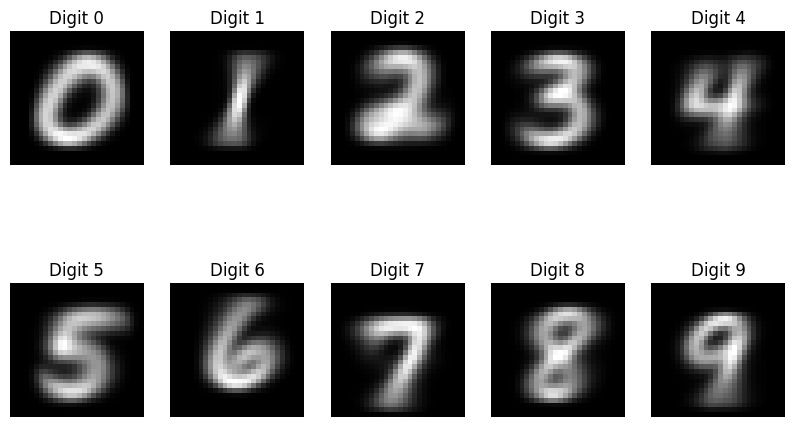

In [22]:
# ======================================================
# STEP 5: AVERAGE DIGIT VISUALIZATION
# ======================================================

plt.figure(figsize=(10,6))

for digit in range(10):

    images = train[train["label"]==digit].drop("label",axis=1)

    avg_image = images.mean().values.reshape(28,28)

    plt.subplot(2,5,digit+1)

    plt.imshow(avg_image, cmap="gray")
    plt.title("Digit " + str(digit))
    plt.axis("off")

plt.show()

In [23]:
# ======================================================
# STEP 6: PREPARE DATA
# ======================================================

X = train.drop("label",axis=1)
y = train["label"]

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (42000, 784)
Label shape: (42000,)


In [24]:
# ======================================================
# STEP 7: NORMALIZE DATA
# ======================================================

X = X / 255.0
test = test / 255.0

In [25]:
# ======================================================
# STEP 8: SPLIT DATA
# ======================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

print("Training samples:",X_train.shape)
print("Validation samples:",X_val.shape)

Training samples: (37800, 784)
Validation samples: (4200, 784)


In [27]:
# ======================================================
# STEP 9: BASELINE MODEL
# ======================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train,y_train)

score = log_model.score(X_val,y_val)

print("Logistic Regression Accuracy:",score)

Logistic Regression Accuracy: 0.9142857142857143


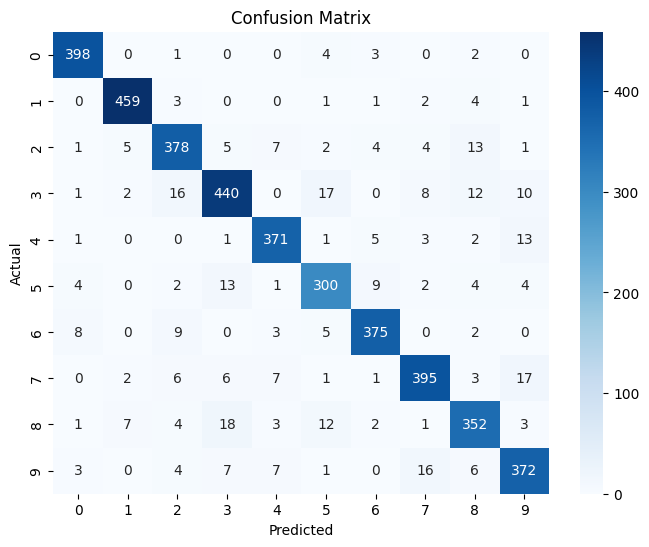

In [29]:
# ======================================================
# STEP 10: CONFUSION MATRIX
# ======================================================

from sklearn.metrics import confusion_matrix

pred = log_model.predict(X_val)

cm = confusion_matrix(y_val,pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [30]:
# ======================================================
# STEP 11: RESHAPE DATA FOR CNN
# ======================================================

X_train = X_train.values.reshape(-1,28,28,1)
X_val = X_val.values.reshape(-1,28,28,1)

test_cnn = test.values.reshape(-1,28,28,1)

y_train = to_categorical(y_train,10)
y_val = to_categorical(y_val,10)

In [15]:
predictions = model.predict(test)
predictions = np.argmax(predictions, axis=1)

557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step


In [31]:
# ======================================================
# STEP 12: CNN MODEL
# ======================================================

model = Sequential()

# Feature extraction
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPool2D((2,2)))

# Convert feature maps to vector
model.add(Flatten())

# Fully connected layers
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(10,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
history = model.fit(

    X_train,
    y_train,

    epochs=10,
    batch_size=64,

    validation_data=(X_val,y_val)

)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 37s 58ms/step - accuracy: 0.9050 - loss: 0.3058 - val_accuracy: 0.9738 - val_loss: 0.0799
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 35s 59ms/step - accuracy: 0.9700 - loss: 0.0992 - val_accuracy: 0.9829 - val_loss: 0.0515
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.9773 - loss: 0.0751 - val_accuracy: 0.9826 - val_loss: 0.0564
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.9826 - loss: 0.0590 - val_accuracy: 0.9871 - val_loss: 0.0396
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - accuracy: 0.9856 - loss: 0.0477 - val_accuracy: 0.9867 - val_loss: 0.0419
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.9865 - loss: 0.0432 - val_accuracy: 0.9893 - val_loss: 0.0296
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 35s 59ms/step - accuracy: 0.9888 - loss: 0.0365 - val_accuracy: 0.9905 - val_loss: 0.0300
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.9903 - loss: 0.0322 - 

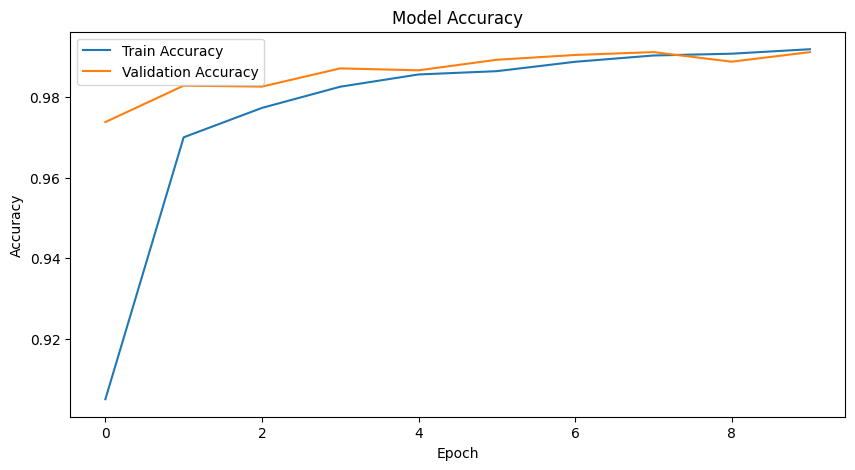

In [35]:
plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"],label="Train Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

In [36]:
predictions = model.predict(test_cnn)

predictions = np.argmax(predictions,axis=1)

557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step


In [37]:
submission = pd.DataFrame({

    "ImageId":range(1,len(predictions)+1),
    "Label":predictions

})

submission.to_csv("submission.csv",index=False)